In [21]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
import re
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import requests
import warnings
warnings.filterwarnings("ignore")
from collections import Counter

In [3]:
movies = pd.read_csv("C:\\Users\\HP\\TMDB\\tmdb_5000_movies.csv")
credits = pd.read_csv("C:\\Users\\HP\\TMDB\\tmdb_5000_credits.csv")

In [4]:
df = movies.merge(credits, left_on='id', right_on='movie_id', how='inner')

In [5]:
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,spoken_languages,status,tagline,title_x,vote_average,vote_count,movie_id,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [6]:
df = df[['movie_id','title_y','genres','keywords','overview','cast','crew']]

In [7]:
df.head()

,movie_id,title_y,genres,keywords,overview,cast,crew
0,19995,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","In the 22nd century, a paraplegic Marine is di...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","Captain Barbossa, long believed to be dead, ha...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",A cryptic message from Bond’s past sends him o...,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",Following the death of District Attorney Harve...,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","John Carter is a war-weary, former military ca...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [8]:
import ast
df['genres'] = df['genres'].apply(ast.literal_eval)
df['keywords'] = df['keywords'].apply(ast.literal_eval)
df['cast'] = df['cast'].apply(ast.literal_eval)
df['crew'] = df['crew'].apply(ast.literal_eval)

In [9]:
df['genres'] = df['genres'].apply(lambda x: [i['name'] for i in x])
df['keywords'] = df['keywords'].apply(lambda x: [i['name'] for i in x])
df['cast'] = df['cast'].apply(lambda x: [i['name'] for i in x[:3]])
df['crew'] = df['crew'].apply(lambda x: [i['name'] for i in x if i['job'] == 'Director'])

In [10]:
df['overview'] = df['overview'].fillna('').apply(lambda x: x.lower())
df['genres'] = df['genres'].apply(lambda x: " ".join(i.lower().replace(" ", "") for i in x))
df['keywords'] = df['keywords'].apply(lambda x: " ".join(i.lower().replace(" ", "") for i in x))
df['cast'] = df['cast'].apply(lambda x: " ".join(i.lower().replace(" ", "") for i in x))
df['crew'] = df['crew'].apply(lambda x: " ".join(i.lower().replace(" ", "") for i in x))

In [11]:
df['tags'] = (
    df['overview'] + " " + 
    df['genres'] + " " + 
    df['keywords'] + " " + 
    df['cast'] + " " + 
    df['crew']
)

In [12]:
cv = CountVectorizer(max_features=5000, stop_words='english')
vector = cv.fit_transform(df['tags']).toarray()

In [13]:
similarity = cosine_similarity(vector)

In [14]:
def recommend(movie):
    index = df[df['title_y'] == movie].index[0]
    distances = list(enumerate(similarity[index]))
    movies_list = sorted(distances, key=lambda x: x[1], reverse=True)[1:6]
    for i in movies_list:
        print(df.iloc[i[0]].title_y)


In [15]:
recommend("Avatar")

Titan A.E.
Independence Day
Small Soldiers
Aliens vs Predator: Requiem
Ender's Game


In [16]:
import pickle
pickle.dump(df, open('movies.pkl', 'wb'))
pickle.dump(similarity, open('similarity.pkl', 'wb'))

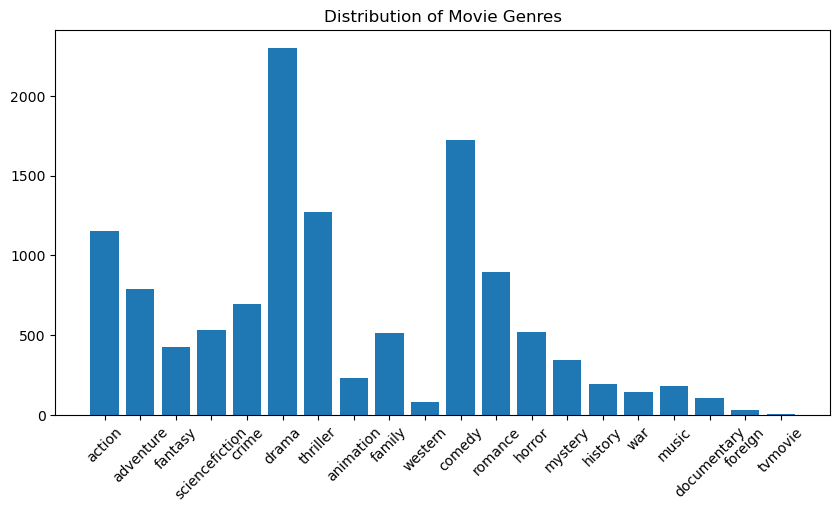

In [20]:
all_genres = " ".join(df['genres']).split()
genre_counts = Counter(all_genres)

plt.figure(figsize=(10,5))
plt.bar(genre_counts.keys(), genre_counts.values())
plt.xticks(rotation=45)
plt.title("Distribution of Movie Genres")
plt.show()

Most movies in this dataset belong to genres like Drama, Comedy, and Action. Since some genres dominate, recommendations may be biased toward these categories.

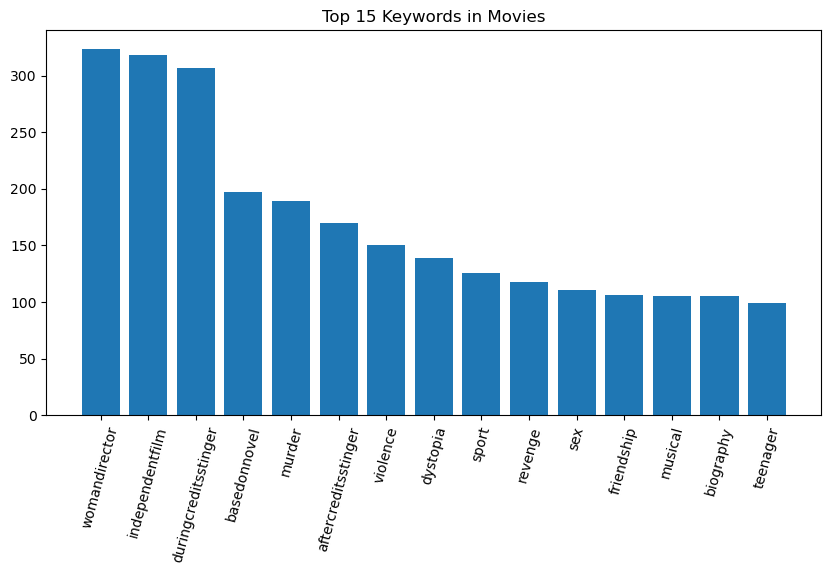

In [18]:
all_keywords = " ".join(df['keywords']).split()
keyword_counts = Counter(all_keywords).most_common(15)

words, counts = zip(*keyword_counts)
plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=75)
plt.title("Top 15 Keywords in Movies")
plt.show()

This gives an idea of what topics are commonly represented in the dataset and what the model may pick up when finding similar movies.